# Web Traffic Analysis – Q1 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load dataset
df = pd.read_csv('WebTraffic_Q1_2025.csv')
df.head()

,VisitDate,SessionDuration,PageViews,ReferralSource,DeviceType,Platform,BounceRate,Conversions
0,2025-03-17,140.78,3.0,Referral,Tablet,Windows,88.24,1
1,2025-01-03,903.04,3.0,Paid Search,Tablet,Windows,48.78,0
2,2025-02-25,395.02,5.0,Social Media,Mobile,macOS,51.13,0
3,2025-01-29,273.88,6.0,Referral,Desktop,macOS,60.36,0
4,2025-03-23,50.89,5.0,Organic Search,Mobile,Linux,88.83,1


## 1. Data Preparation

In [2]:
# Convert 'VisitDate' to datetime
df['VisitDate'] = pd.to_datetime(df['VisitDate'])

df['Month'] = df['VisitDate'].dt.month_name()
df['DayOfWeek'] = df['VisitDate'].dt.day_name()
df['Week'] = df['VisitDate'].dt.isocalendar().week

# Handle missing values
df['SessionDuration'] = df['SessionDuration'].fillna(df['SessionDuration'].mean())
df['PageViews'] = df['PageViews'].fillna(df['PageViews'].median())
df.head()

,VisitDate,SessionDuration,PageViews,ReferralSource,DeviceType,Platform,BounceRate,Conversions,Month,DayOfWeek,Week
0,2025-03-17,140.78,3.0,Referral,Tablet,Windows,88.24,1,March,Monday,12
1,2025-01-03,903.04,3.0,Paid Search,Tablet,Windows,48.78,0,January,Friday,1
2,2025-02-25,395.02,5.0,Social Media,Mobile,macOS,51.13,0,February,Tuesday,9
3,2025-01-29,273.88,6.0,Referral,Desktop,macOS,60.36,0,January,Wednesday,5
4,2025-03-23,50.89,5.0,Organic Search,Mobile,Linux,88.83,1,March,Sunday,12


## 2. Traffic Trend Analysis

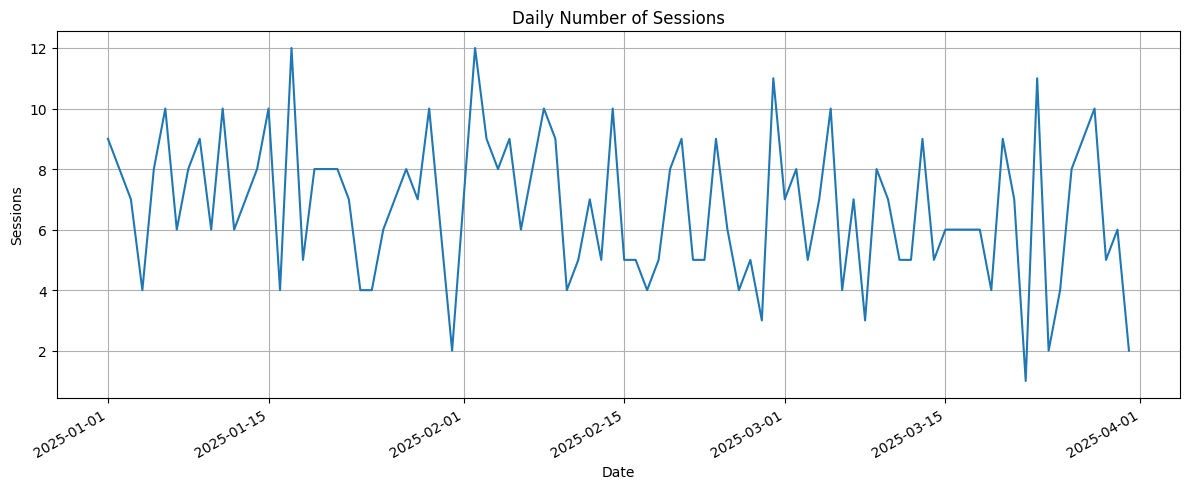

In [3]:
# Daily number of sessions
daily_sessions = df.groupby('VisitDate').size()

'''
The `size()` method in the line:

df.groupby('VisitDate').size() is used to count the number of rows (i.e., occurrences or entries) in each group formed by `groupby()`.

### Here's what happens step by step:

1. `df.groupby('VisitDate')`:  
   Groups the DataFrame by each unique `VisitDate`.

2. `.size()`:  
   Counts the number of entries (rows) in each group, returning a `Series` with the `VisitDate` as the index and the count as the value.

### Example:
Suppose the `df` has this data:

| VisitDate  | SessionID |
|------------|-----------|
| 2025-01-01 | A1        |
| 2025-01-01 | A2        |
| 2025-01-02 | A3        |

Then:
df.groupby('VisitDate').size()

Would return:

VisitDate
2025-01-01    2
2025-01-02    1
dtype: int64

This tells you that:
- 2 sessions occurred on Jan 1, 2025
- 1 session occurred on Jan 2, 2025
'''

plt.figure(figsize=(12, 5))
daily_sessions.plot()
plt.title('Daily Number of Sessions')
plt.xlabel('Date')
plt.ylabel('Sessions')
plt.grid(True)
plt.tight_layout()
plt.show()

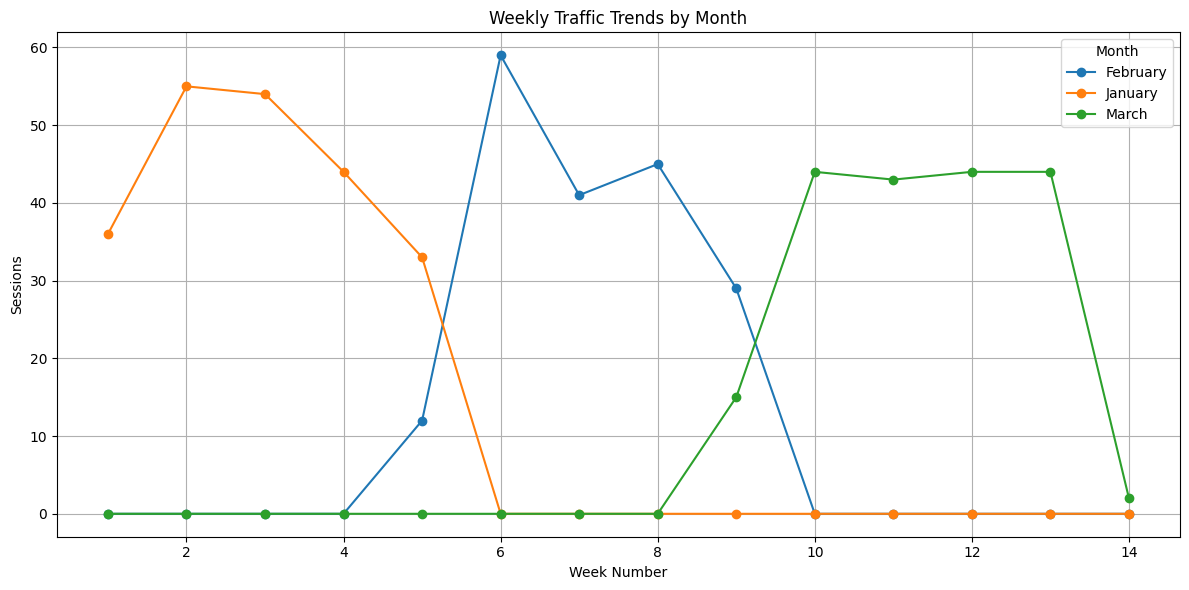

In [4]:
# Weekly traffic trends by month
weekly_trends = df.groupby(['Week', 'Month']).size().unstack().fillna(0)

'''
The expression:

df.groupby(['Week', 'Month']).size().unstack().fillna(0)
is used to create a pivot-style table showing the count of records per week, 
broken down by month. 

Let’s break it down:

---

### 1. `df.groupby(['Week', 'Month'])`
This groups the DataFrame by both `Week` and `Month`.

Example group structure:
(Week 1, January), (Week 2, January), (Week 1, February), ...

---

### 2. `.size()`
Counts the number of rows (sessions/visits) in each `(Week, Month)` group.

Output so far (MultiIndex Series):
Week  Month
1     January     12
1     February     5
2     January     20
2     February    10
...

---

### 3. `.unstack()`
"Unstacks" the `Month` index level to become columns instead of part of the row index.

Now you get a table like:
| Week | January | February | March |
|------|---------|----------|-------|
| 1    |   12    |    5     |  NaN  |
| 2    |   20    |   10     |   8   |

---

### 4. `.fillna(0)`
Replaces all `NaN` values (which indicate no data for a week-month pair) with `0`.

Final output:
| Week | January | February | March |
|------|---------|----------|-------|
| 1    |   12    |    5     |   0   |
| 2    |   20    |   10     |   8   |

---

### Purpose:
To easily visualize or plot weekly session counts broken down by month, 
where missing combinations are filled with `0` instead of `NaN`.
'''

weekly_trends.plot(figsize=(12, 6), marker='o')
plt.title('Weekly Traffic Trends by Month')
plt.xlabel('Week Number')
plt.ylabel('Sessions')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. User Engagement Metrics

In [5]:
# Average metrics
avg_session_duration = df['SessionDuration'].mean()
avg_page_views = df['PageViews'].mean()

print(f'Average Session Duration: {avg_session_duration:.2f} seconds')
print(f'Average Page Views per Session: {avg_page_views:.2f}')

Average Session Duration: 310.73 seconds
Average Page Views per Session: 4.95


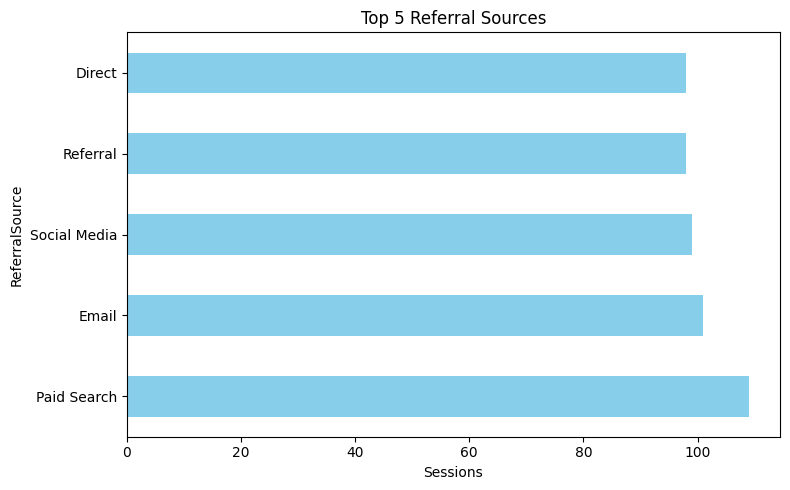

In [6]:
# Top 5 referral sources
top_referrals = df['ReferralSource'].value_counts().head(5)

top_referrals.plot(kind='barh', figsize=(8, 5), color='skyblue')
plt.title('Top 5 Referral Sources')
plt.xlabel('Sessions')
plt.tight_layout()
plt.show()

## 4. Conversion Analysis

In [7]:
# Conversion rate
conversion_rate = df['Conversions'].mean() * 100

print(f'Overall Conversion Rate: {conversion_rate:.2f}%')

Overall Conversion Rate: 14.33%


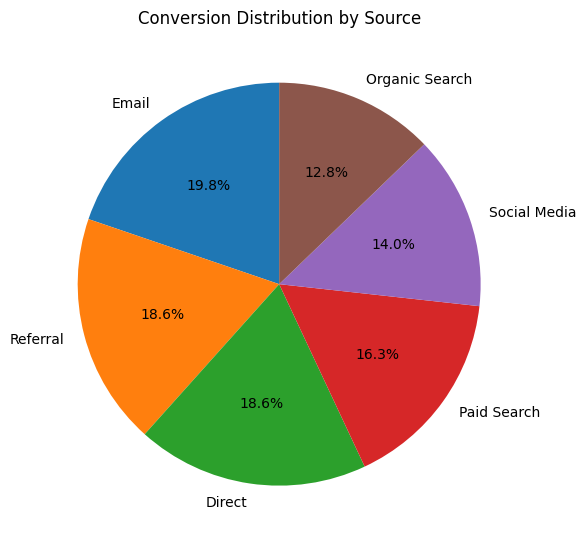

In [8]:
# Pie chart by source
source_conversions = df[df['Conversions'] == 1]['ReferralSource'].value_counts()

source_conversions.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), startangle=90)
plt.title('Conversion Distribution by Source')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Device & Platform Insights

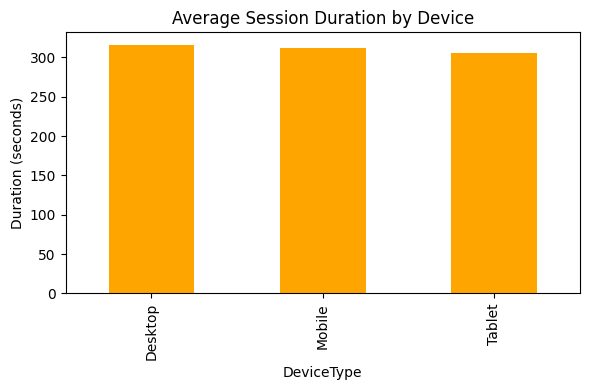

In [9]:
# Average session duration by device
device_duration = df.groupby('DeviceType')['SessionDuration'].mean()

device_duration.plot(kind='bar', figsize=(6, 4), color='orange')
plt.title('Average Session Duration by Device')
plt.ylabel('Duration (seconds)')
plt.tight_layout()
plt.show()

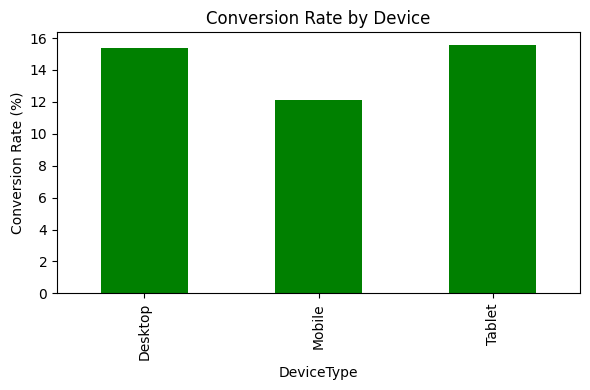

In [10]:
# Conversion rate by device
device_conversion = df.groupby('DeviceType')['Conversions'].mean() * 100

device_conversion.plot(kind='bar', figsize=(6, 4), color='green')
plt.title('Conversion Rate by Device')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

## 6. Bounce Rate Pattern

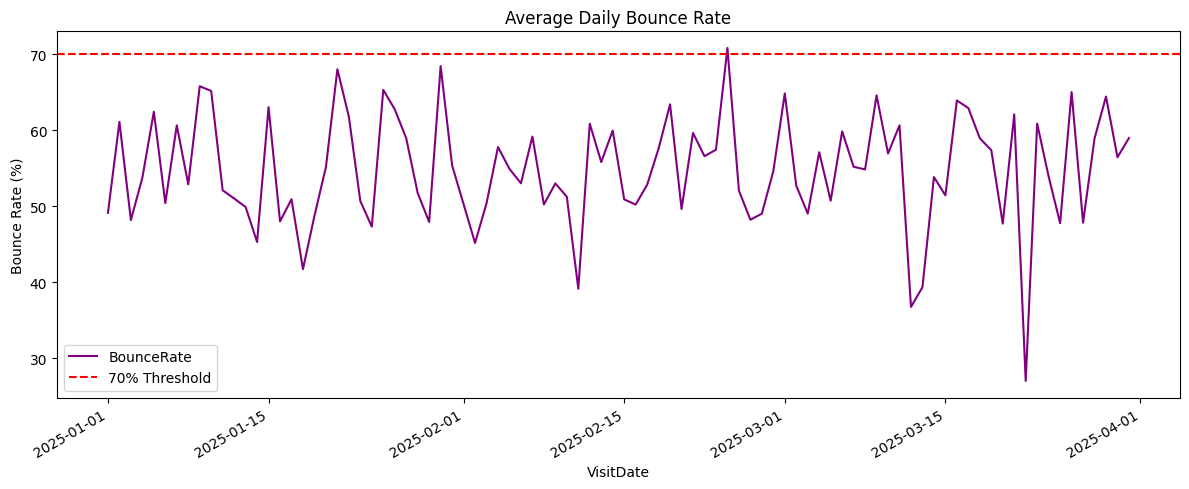

In [ ]:
# Daily average bounce rate
daily_bounce = df.groupby('VisitDate')['BounceRate'].mean()

daily_bounce.plot(figsize=(12, 5), color='purple')

plt.axhline(70, color='red', linestyle='--', label='70% Threshold')

plt.title('Average Daily Bounce Rate')
plt.ylabel('Bounce Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()